## Titanic - Logistic Regression

## Kütüphaneler

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

## Fonksiyonlar

In [2]:
def load_data(path):
    # Bu fonksiyon veriyi yüklemek için yazıldı.
    df=pd.read_csv(path)
    return df

In [3]:
def explore_data(df):
    # Bu fonksiyon veri keşifi için yazıldı.
    print(df.shape)
    print(df.info())
    print(df.isnull().sum())
    print(df["Survived"].value_counts())
    return df.head()

In [4]:
def clean_data(df):
    # Bu fonksiyon veri temizliği ve manipülasyonu için yazıldı.
    df["Title"] = df["Name"].str.split(", ").str[1].str.split(".").str[0]
    rare = df["Title"].value_counts()
    rare = rare[rare < 10].index
    df["Title"] = df["Title"].replace(rare, "Rare")
    df["FamilySize"]=df["SibSp"]+df["Parch"]+1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df = df.drop(columns=["Cabin", "Ticket", "PassengerId", "Name"])
    df = df.dropna(subset=["Embarked"])
    df["Title"]=df["Title"].map({"Mr":0, "Mrs":1, "Miss":2, "Master":3, "Rare":4})
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Embarked"] = df["Embarked"].map({"S":0, "C":1, "Q":2})
    df["Sex"] = df["Sex"].map({"male":0, "female":1})
    return df

In [5]:
def split_data(df):
    # Bu fonksiyon verimizi Train / Test olarak ayırmayı sağlar.
    X=df.drop(columns="Survived")
    y=df["Survived"]
    X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test, X, y

In [6]:
def build_model(X_train, y_train):
    # Bu fonksiyon modelimizi oluşturur ve eğitir.
    my_model=Pipeline(
        [
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression())
        ]
    )
    my_model.fit(X_train, y_train)
    return my_model

In [12]:
def tune_model(X_train, y_train):
    # bu fonksiyon modelimizin performansını maksimize etmek için yazıldı.
    my_model=Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression())
    ])
    params=[
        {"lr__C":[0.01,0.1,1,10,100] ,"lr__penalty":["l2"] ,"lr__solver":["lbfgs"]},
        {"lr__C":[0.01,0.1,1,10,100] ,"lr__penalty":["l1"] ,"lr__solver":["liblinear"]}
]
    grid_cv=GridSearchCV(my_model,param_grid=params,n_jobs=-1)
    grid_cv.fit(X_train, y_train)
    print(grid_cv.best_params_)
    print(grid_cv.best_score_)
    return grid_cv.best_estimator_

In [8]:
def evaluate_model(model, X_test, y_test):
    # Bu fonksiyon modelimizin başarısını ölçer.
    y_pred=model.predict(X_test)
    print(f"Accuracy Score : {accuracy_score(y_test, y_pred)}")
    print(f"Classification Report : {classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)}")
    return y_pred

In [9]:
def plot_confusion_matrix(y_test, y_pred):
    # Bu fonksiyon confusion matrix değerlerimizi görselleştirir.
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=[0,1],
        yticklabels=[0,1]
    )
    plt.title("Hayatta Kalma Durumu - Titanic")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

In [10]:
def cross_validate_model(model, X, y):
    # Modelimizin başarısını veriyi her seferinde farklı şekilde bölerek ölçüyoruz. Bu sonuçlar tesadüf mü değil mi ?
    scores=cross_val_score(model, X, y, cv=5)
    for i,score in enumerate(scores,1):
        print(f"{i}.fold skoru: {score}")
    print(f"Skorların ortalaması : {scores.mean()}")
    print(f"Skorların standart sapması : {scores.std()}")

## Çalıştırma Ve Sonuçlar

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
d

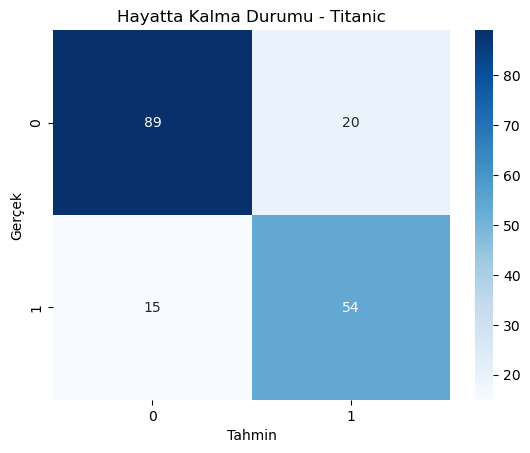

1.fold skoru: 0.8033707865168539
2.fold skoru: 0.797752808988764
3.fold skoru: 0.7865168539325843
4.fold skoru: 0.8033707865168539
5.fold skoru: 0.8135593220338984
Skorların ortalaması : 0.8009141115977909
Skorların standart sapması : 0.008823227445255367

Optimize edilmiş parametreler ile oluşturulan modelin sonuçları:
{'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
0.8143110410716045
Accuracy Score : 0.8033707865168539
Classification Report :               precision    recall  f1-score   support

           0       0.86      0.82      0.84       109
           1       0.73      0.78      0.76        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.80       178
weighted avg       0.81      0.80      0.80       178

Confusion Matrix : [[89 20]
 [15 54]]


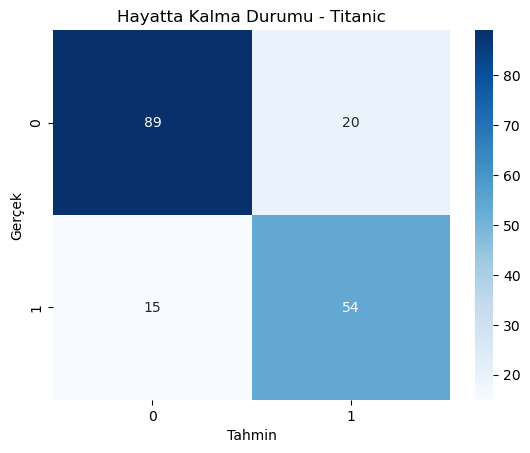

1.fold skoru: 0.8033707865168539
2.fold skoru: 0.797752808988764
3.fold skoru: 0.7865168539325843
4.fold skoru: 0.8033707865168539
5.fold skoru: 0.8135593220338984
Skorların ortalaması : 0.8009141115977909
Skorların standart sapması : 0.008823227445255367


In [11]:
if __name__=="__main__":
    df=load_data("train.csv")
    explore_data(df)
    df=clean_data(df)
    X_train, X_test, y_train, y_test, X, y=split_data(df)
    # default model
    print("Default parametreler ile oluşturulan modelin sonuçları:")
    my_model=build_model(X_train, y_train)
    y_pred=evaluate_model(my_model, X_test, y_test)
    plot_confusion_matrix(y_test, y_pred)
    cross_validate_model(my_model, X, y)
    print()
    print("Optimize edilmiş parametreler ile oluşturulan modelin sonuçları:")
    best_estimator=tune_model(X_train, y_train)
    y_pred_best=evaluate_model(best_estimator, X_test, y_test)
    plot_confusion_matrix(y_test, y_pred_best)
    cross_validate_model(best_estimator, X, y)